In [36]:
import pickle
from pathlib import Path

MODEL_PATH = Path("../models/stress_som_model_200hz_ver3_30x30.pkl")

with open(MODEL_PATH, "rb") as f:
    som_model = pickle.load(f)

print("✅ Modell laddad\n")

print("Grid:", som_model.x, "x", som_model.y)
print("Input length:", som_model.input_len)
print("Trained:", som_model.is_trained)
print("Cluster method:", som_model.cluster_method)

print("\nScaler median:", som_model.scaler.center_)
print("Scaler IQR:", som_model.scaler.scale_)

print("\nCluster labels:", som_model.cluster_labels)

weights = som_model.som.get_weights()
print("Weights shape:", weights.shape)

✅ Modell laddad

Grid: 30 x 30
Input length: 6
Trained: True
Cluster method: density

Scaler median: [78.33363592 58.29793005 56.80046013  0.          6.76972787 -2.07128355]
Scaler IQR: [14.68643181 53.73327785 36.04296775  0.69314718  0.30947827  2.09140681]

Cluster labels: {0: 'Baseline', 1: 'Relax', 2: 'Stress'}
Weights shape: (30, 30, 6)


In [37]:
from pathlib import Path

DATA_PATH = Path("test_features_windows")

files = sorted(DATA_PATH.glob("participant_*_windows.csv"))

print("Found:", len(files))
for f in files:
    print(f.name)

Found: 12
participant_49_windows.csv
participant_50_windows.csv
participant_51_windows.csv
participant_52_windows.csv
participant_53_windows.csv
participant_54_windows.csv
participant_55_windows.csv
participant_56_windows.csv
participant_57_windows.csv
participant_58_windows.csv
participant_59_windows.csv
participant_60_windows.csv


In [38]:
blocks = [
    ("baseline", 60),
    ("mathtest", 168),
    ("mathtest_answer", 5),
    ("neutral", 30),
    ("strooptest", 180),
    ("strooptest_answer", 5),
    ("neutral", 30),
    ("IQ_test", 300),
    ("IQ_test_answer", 5),
    ("neutral", 30),
    ("pics", 80),
    ("neutral", 30),
    ("pics", 80),
    ("neutral", 30),
    ("pics", 80),
    ("neutral", 30),
    ("pics", 80),
    ("neutral", 30),
    ("video", 60), ("video", 60), ("video", 60), ("video", 60),
    ("neutral", 30),
    ("video", 60), ("video", 60), ("video", 60), ("video", 60),
    ("neutral", 30),
    ("video", 60), ("video", 60), ("video", 60), ("video", 60),
    ("neutral", 30),
    ("video", 60), ("video", 60), ("video", 60), ("video", 60),
]

In [39]:
def assign_blocks(df):

    current_time = 0

    for name, duration in blocks:
        start = current_time
        end = current_time + duration

        mask = (df["time_sec"] >= start) & (df["time_sec"] < end)
        df.loc[mask, "block"] = name

        current_time = end

    return df

In [40]:
import pandas as pd
import numpy as np

FEATURE_COLUMNS = [
    "HR",
    "HRV_RMSSD",
    "HRV_SDNN",
    "SCR_Count",
    "EDA_Tonic_log",
    "EDA_Phasic_log"
]

all_results = []

for file in files:

    pid = int(file.stem.split("_")[1])

    df_p = pd.read_csv(file)

    # -------------------------
    # Predict
    # -------------------------
    X = df_p[FEATURE_COLUMNS].values

    clusters = som_model.predict_cluster(X)

    df_p["cluster"] = clusters
    df_p["label"] = [som_model.get_cluster_name(c) for c in clusters]

    # -------------------------
    # Add participant
    # -------------------------
    df_p["participant"] = pid

    # -------------------------
    # Assign blocks
    # -------------------------
    df_p = assign_blocks(df_p)

    all_results.append(df_p)

# combine
df = pd.concat(all_results, ignore_index=True)

print("Final shape:", df.shape)
df.head()

Final shape: (35356, 11)


,HR,HRV_RMSSD,HRV_SDNN,SCR_Count,participant,time_sec,EDA_Tonic_log,EDA_Phasic_log,cluster,label,block
0,81.081141,94.392796,79.096460,1.386294,49,0,6.0,2.000000,0,Baseline,baseline
1,81.326360,93.076283,78.031333,1.098612,49,1,6.0,1.691600,0,Baseline,baseline
2,81.558277,91.003181,76.383329,1.098612,49,2,6.0,1.447524,0,Baseline,baseline
3,81.827108,89.843168,75.454180,1.098612,49,3,6.0,1.399468,0,Baseline,baseline
4,80.391178,40.793413,35.169917,0.693147,49,4,6.0,0.816053,0,Baseline,baseline


In [41]:
block_dist = (
    df.groupby("block")["label"]
    .value_counts(normalize=True)
    .unstack()
    .fillna(0)
)

print(block_dist)

label              Baseline     Relax    Stress
block                                          
IQ_test            0.878333  0.063611  0.058056
IQ_test_answer     0.750000  0.166667  0.083333
baseline           0.559722  0.440278  0.000000
mathtest           0.836310  0.163690  0.000000
mathtest_answer    0.833333  0.166667  0.000000
neutral            0.861944  0.111389  0.026667
pics               0.884375  0.063281  0.052344
strooptest         0.878241  0.094907  0.026852
strooptest_answer  0.833333  0.083333  0.083333
video              0.814410  0.185417  0.000174


In [42]:
participant_summary = (
    df.groupby("participant")["label"]
    .value_counts(normalize=True)
    .unstack()
    .fillna(0)
)

print(participant_summary)

label        Baseline     Relax    Stress
participant                              
49           0.695461  0.304539  0.000000
50           0.996951  0.003049  0.000000
51           0.977612  0.022388  0.000000
52           0.870257  0.129743  0.000000
53           0.978622  0.021378  0.000000
54           0.618256  0.381744  0.000000
55           0.619487  0.355556  0.024957
56           0.999661  0.000339  0.000000
57           0.974542  0.025458  0.000000
58           0.779776  0.049542  0.170682
59           0.978955  0.021045  0.000000
60           0.980658  0.019342  0.000000


In [43]:
from scipy.stats import ttest_ind

def stress_ratio(df, block):
    return (
        df[df["block"] == block]
        .groupby("participant")["label"]
        .apply(lambda x: (x == "Stress").mean())
    )

baseline = stress_ratio(df, "baseline")
stress = stress_ratio(df, "mathtest")

t_stat, p_val = ttest_ind(stress, baseline)

print("t =", t_stat)
print("p =", p_val)

t = nan
p = nan


ValueError: 'c' argument must be a color, a sequence of colors, or a sequence of numbers, not 0       orange
1       orange
2       orange
3       orange
4       orange
         ...  
2947    orange
2948    orange
2949    orange
2950    orange
2951    orange
Name: label, Length: 2952, dtype: str

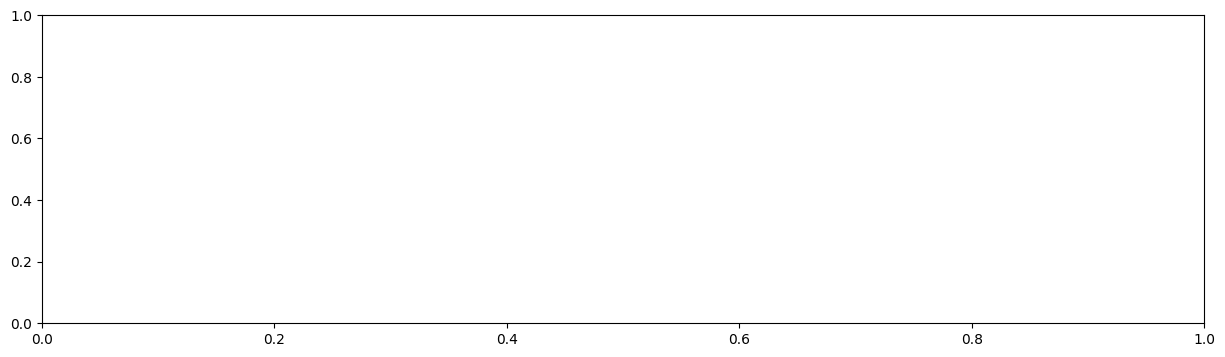

In [45]:
import matplotlib.pyplot as plt

pid = 49
df_p = df[df["participant"] == pid]

# färg per label
color_map = {
    "Relaxed": "green",
    "Stress": "red",
    "Baseline": "orange"
}

colors = df_p["label"].map(color_map)

plt.figure(figsize=(15,4))

plt.scatter(df_p["time_sec"], df_p["cluster"], c=colors, s=10)

plt.title(f"Participant {pid} - State over time")
plt.xlabel("Time (sec)")
plt.ylabel("Cluster")

plt.yticks([0,1,2], ["Relaxed", "Stress", "Cognitive"])

plt.show()

In [51]:
expected_map = {
    "baseline": "baseline",
    "neutral": "Relax",

    "mathtest": "Stress",
    "strooptest": "Stress",

    "IQ_test": "Stess",

    # ignore answers
    "mathtest_answer": None,
    "strooptest_answer": None,
    "IQ_test_answer": None,

    # stimuli (kan diskuteras)
    "pics": "Stress",
    "video": "Stress"
}

In [47]:
df["expected"] = df["block"].map(expected_map)

# ta bort de vi inte vill utvärdera
df_eval = df.dropna(subset=["expected"])

In [48]:
df_eval["correct"] = df_eval["label"] == df_eval["expected"]

accuracy = df_eval["correct"].mean()

print("Accuracy:", accuracy)
print("Error rate:", 1 - accuracy)

Accuracy: 0.009506118881118882
Error rate: 0.9904938811188811


In [49]:
block_acc = (
    df_eval.groupby("block")["correct"]
    .mean()
)

print(block_acc)

block
IQ_test       0.000000
baseline      0.000000
mathtest      0.000000
neutral       0.000000
pics          0.052344
strooptest    0.026852
video         0.000174
Name: correct, dtype: float64


In [52]:
from sklearn.metrics import confusion_matrix
import pandas as pd

labels = ["Relax", "Stress", "Baseline"]

cm = confusion_matrix(
    df_eval["expected"],
    df_eval["label"],
    labels=labels
)

cm_df = pd.DataFrame(cm, index=labels, columns=labels)

print(cm_df)

          Relax  Stress  Baseline
Relax         0       0         0
Stress     2914     261     16361
Baseline      0       0         0


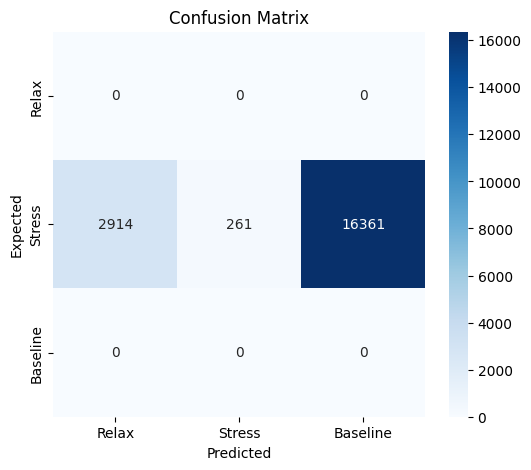

In [53]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))
sns.heatmap(cm_df, annot=True, fmt="d", cmap="Blues")

plt.xlabel("Predicted")
plt.ylabel("Expected")
plt.title("Confusion Matrix")

plt.show()

In [54]:

df = pd.read_csv("test_features_stroop/stroop_49_60_ALL_WINDOWS.csv")

print(df.shape)
df.head()

(2412, 8)


,HR,HRV_RMSSD,HRV_SDNN,SCR_Count,participant,time_sec,EDA_Tonic_log,EDA_Phasic_log
0,76.163098,29.860788,25.456788,1.609438,49,0,6.0,1.108721
1,76.267124,29.465968,25.664705,1.609438,49,1,6.0,0.755006
2,76.364362,29.864559,25.373806,1.609438,49,2,6.0,-0.093582
3,76.438819,30.174929,25.178177,1.609438,49,3,6.0,-3.881449
4,76.472527,30.123619,24.654079,1.609438,49,4,6.0,-1.221619


In [55]:
FEATURE_COLUMNS = [
    "HR",
    "HRV_RMSSD",
    "HRV_SDNN",
    "SCR_Count",
    "EDA_Tonic_log",
    "EDA_Phasic_log"
]

X_stroop = df[FEATURE_COLUMNS].values

clusters = som_model.predict_cluster(X_stroop)
df["label"] = [som_model.get_cluster_name(c) for c in clusters]

print(df["label"].value_counts(normalize=True))

label
Baseline    0.920813
Relax       0.055141
Stress      0.024046
Name: proportion, dtype: float64


In [57]:
df["expected"] = "Stress"

df["correct"] = df["label"] == df["expected"]

accuracy = df["correct"].mean()

print("Accuracy (Stress detection):", accuracy)
print("Error rate:", 1 - accuracy)

Accuracy (Stress detection): 0.02404643449419569
Error rate: 0.9759535655058043


In [58]:
participant_acc = (
    df.groupby("participant")["correct"]
    .mean()
)

print(participant_acc)

participant
49    0.000000
50    0.000000
51    0.000000
52    0.000000
53    0.000000
54    0.000000
55    0.306878
56    0.000000
57    0.000000
58    0.000000
59    0.000000
60    0.000000
Name: correct, dtype: float64


In [60]:
from sklearn.metrics import confusion_matrix
import pandas as pd

labels = ["Relaxed", "Stress", "Baseline"]

cm = confusion_matrix(
    df["expected"],
    df["label"],
    labels=labels
)

cm_df = pd.DataFrame(cm, index=["Expected Stress"], columns=labels)

print(cm_df)

ValueError: Shape of passed values is (3, 3), indices imply (1, 3)

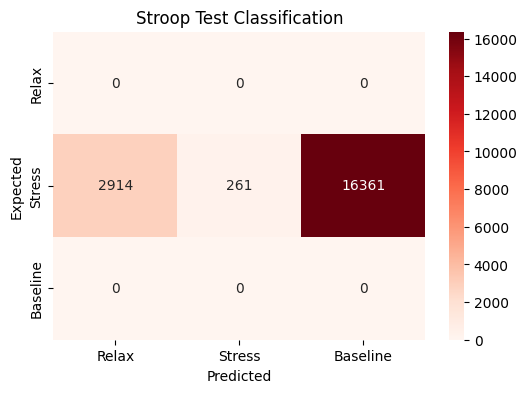

In [61]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
sns.heatmap(cm_df, annot=True, cmap="Reds", fmt="d")

plt.title("Stroop Test Classification")
plt.xlabel("Predicted")
plt.ylabel("Expected")

plt.show()

In [62]:
feature_means = df.groupby("label")[FEATURE_COLUMNS].mean()

print(feature_means)

                 HR   HRV_RMSSD    HRV_SDNN  SCR_Count  EDA_Tonic_log  \
label                                                                   
Baseline  86.595970   66.007969   53.951409   0.856430       6.011973   
Relax     76.392867  165.208756  114.621608   1.054891       6.044257   
Stress    82.504545   87.756047   94.176272   0.991918       7.999798   

          EDA_Phasic_log  
label                     
Baseline       -1.846856  
Relax          -0.731713  
Stress          2.000000  


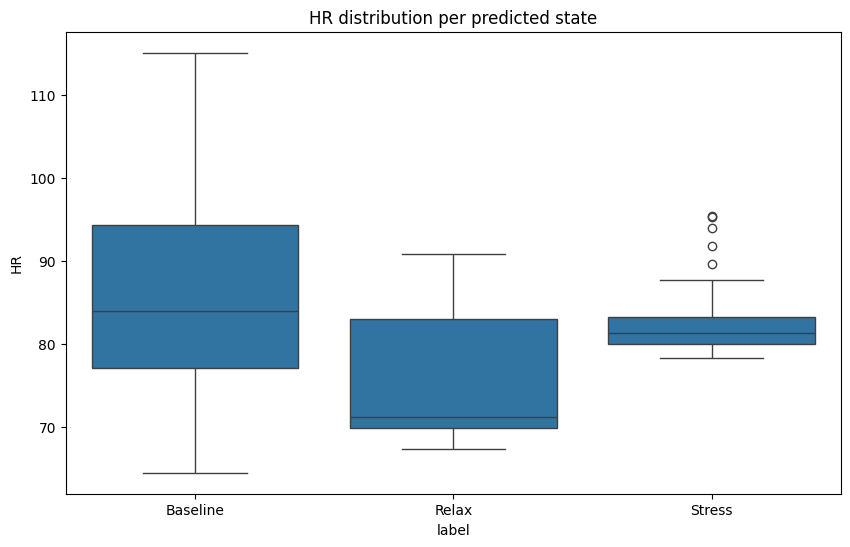

In [63]:
plt.figure(figsize=(10,6))
sns.boxplot(data=df, x="label", y="HR")

plt.title("HR distribution per predicted state")
plt.show()

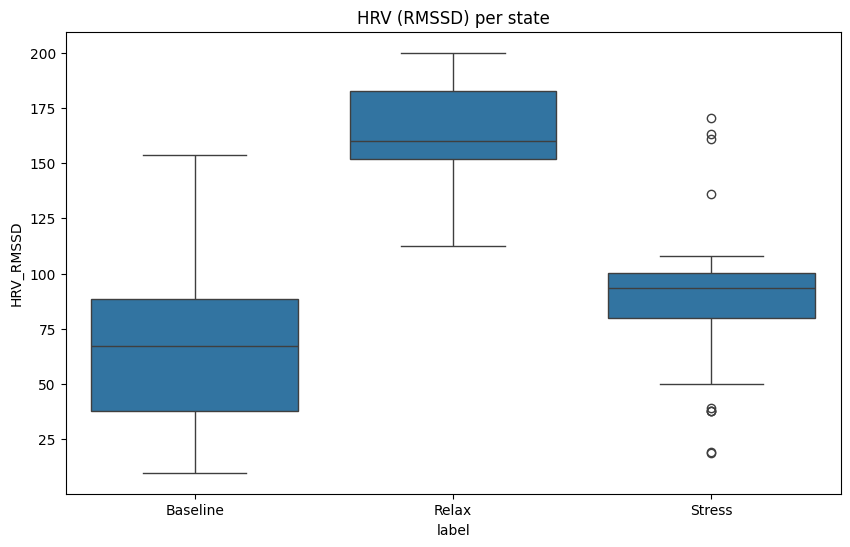

In [64]:
plt.figure(figsize=(10,6))
sns.boxplot(data=df, x="label", y="HRV_RMSSD")

plt.title("HRV (RMSSD) per state")
plt.show()

In [65]:
pid = 55
df_p = df[df["participant"] == pid]

print(df_p["label"].value_counts(normalize=True))

label
Baseline    0.555556
Stress      0.306878
Relax       0.137566
Name: proportion, dtype: float64


In [66]:
df["is_correct"] = df["label"] == "Stress"

comparison = df.groupby("is_correct")[FEATURE_COLUMNS].mean()

print(comparison)

                   HR  HRV_RMSSD   HRV_SDNN  SCR_Count  EDA_Tonic_log  \
is_correct                                                              
False       85.954356  72.394080  57.857089   0.867643       6.014003   
True        82.504545  87.756047  94.176272   0.991918       7.999798   

            EDA_Phasic_log  
is_correct                  
False            -1.776732  
True              2.000000  


In [67]:
errors = df[df["label"] != "Stress"]

print(errors[FEATURE_COLUMNS].describe())

                HR    HRV_RMSSD     HRV_SDNN    SCR_Count  EDA_Tonic_log  \
count  2115.000000  2066.000000  2066.000000  2354.000000    2115.000000   
mean     85.954356    72.394080    57.857089     0.867643       6.014003   
std      12.674924    39.021281    25.463170     0.625407       0.105016   
min      64.516129     9.805807    12.006942     0.000000       6.000000   
25%      76.701669    40.558869    40.096429     0.000000       6.000000   
50%      83.548250    69.669089    55.987394     1.098612       6.000000   
75%      93.140797    94.669510    73.590696     1.386294       6.000000   
max     115.141677   200.000000   149.645660     2.079442       8.000000   

       EDA_Phasic_log  
count     2115.000000  
mean        -1.776732  
std          1.443024  
min         -4.000000  
25%         -2.805025  
50%         -1.814091  
75%         -0.894552  
max          2.000000  


In [ ]:
stress_ratio = (
    df.groupby("participant")["label"]
    .apply(lambda x: (x == "Stress").mean())
)

print(stress_ratio)